# Notebook 1: Data Exploration

**Sequential Transfer Learning for Medicinal Plant Identification**

---

## Purpose

This notebook explores all 5 datasets used in the dissertation project:

| Dataset | Purpose | Species |
|---------|---------|--------|
| Dataset 1 | Phase 1: General features | 6 (Arjun, Curry, Marsh Pennywort, Mint, Neem, Rubble) |
| Dataset 2 | Phase 2: Regional adaptation (Bangladesh) | 6 species |
| Dataset 3 | **Test set** (held out for final evaluation) | 9 species |
| Dataset 4 | Phase 3a: Endangered species (Bangladesh) | 16 species |
| Dataset 5 | Phase 3b: Commercial species (South India) | 20 species |

---

## Google Drive Storage

**This notebook saves datasets to your Google Drive so you don't have to re-download every session!**

- First run: Downloads datasets (~10-15 min) and saves to Drive
- Future runs: Loads from Drive instantly!

## 1. Mount Google Drive (Important!)

This saves your data permanently. You'll only download once!

In [ ]:
# Mount Google Drive for persistent storage
from google.colab import drive

print(">>> Mounting Google Drive...")
print("   (Click 'Connect to Google Drive' when prompted)\n")

drive.mount('/content/drive')  # mounts drive to /content/drive

print("\n>>>>> Google Drive mounted!")
print("   Your data will be saved permanently.")

>>> Mounting Google Drive...
   (Click 'Connect to Google Drive' when prompted)

Mounted at /content/drive

>>>>> Google Drive mounted!
   Your data will be saved permanently.


In [ ]:
# Import libraries
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import requests
from tqdm import tqdm  # progress bar for downloads

print(">>> Libraries imported")

>>> Libraries imported


In [ ]:
# Configuration - USING GOOGLE DRIVE FOR PERSISTENCE

# Data will be saved to your Google Drive
DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")   # all datasets go here
MODEL_DIR = os.path.join(PROJECT_DIR, "models") # trained models go here

# Create directories
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(">>> Project Structure (in Google Drive):")
print(f"   {PROJECT_DIR}")
print(f"   ├── data/      <- Datasets saved here")
print(f"   └── models/    <- Trained models saved here")
print("\n>>>>> Files in Google Drive persist between sessions!")

>>> Project Structure (in Google Drive):
   /content/drive/MyDrive/MedicinalPlant_Dissertation
   ├── data/      <- Datasets saved here
   └── models/    <- Trained models saved here

>>>>> Files in Google Drive persist between sessions!


In [ ]:
# Dataset URLs (Mendeley Data - Correct API Links)
DATASETS = {
    "dataset1": {
        "url": "https://data.mendeley.com/public-api/zip/fj93rrfv2y/download/2",
        "name": "Medicinal Plant Identification Dataset",
        "purpose": "Phase 1: General Features",
        "species": 6,
        "species_list": "Arjun Leaf, Curry Leaf, Marsh Pennywort, Mint, Neem, Rubble Leaf"
    },
    "dataset2": {
        "url": "https://data.mendeley.com/public-api/zip/skvrd2s9gg/download/3",
        "name": "Bangladeshi Medicinal Plants",
        "purpose": "Phase 2: Regional Adaptation",
        "species": 6,
        "species_list": "Centella Asiatica, Coccinia Grandis, Eclipta Prostrata, Mikania Micrantha, Murraya Koenigii, Stephania Japonica"
    },
    "dataset3": {
        "url": "https://data.mendeley.com/public-api/zip/k8m93ft9kk/download/2",
        "name": "Medicinal Leaf Dataset",
        "purpose": "TEST SET (Hold out)",
        "species": 9,
        "species_list": "Betel, Fenugreek, Curry Tree, Mint, Tora, Coriander, Onion, Radish, Aloe Vera"
    },
    "dataset4": {
        "url": "https://data.mendeley.com/public-api/zip/hnwrxg8zm8/download/1",
        "name": "REMP: Rare and Endangered Medicinal Plants Bangladesh",
        "purpose": "Phase 3a: Endangered Species",
        "species": 16,
        "species_list": "16 types of rare and endangered medicinal plants"
    },
    "dataset5": {
        "url": "https://data.mendeley.com/public-api/zip/9d89vjcghv/download/2",
        "name": "SIMPD V1: South Indian Medicinal Plants",
        "purpose": "Phase 3b: Commercial Species",
        "species": 20,
        "species_list": "Abutilon Indicum, Aloe barbadensis, Calotropis gigantea, and 17 more"
    }
}

print(f">>> Total datasets: {len(DATASETS)}")
print("\nDataset Details:")
for name, info in DATASETS.items():
    print(f"   {name}: {info['species']} species - {info['purpose']}")

>>> Total datasets: 5

Dataset Details:
   dataset1: 6 species - Phase 1: General Features
   dataset2: 6 species - Phase 2: Regional Adaptation
   dataset3: 9 species - TEST SET (Hold out)
   dataset4: 16 species - Phase 3a: Endangered Species
   dataset5: 20 species - Phase 3b: Commercial Species


## 2. Download Datasets (Only Once!)

This downloads to Google Drive. **You only need to do this once** - next time you run, it will skip the download!

In [ ]:
def download_with_requests(url, destination, dataset_name):
    """Download file using requests with proper headers for Mendeley."""

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.5',
        'Connection': 'keep-alive',
    }

    try:
        print(f"  >>> Downloading {dataset_name}...")

        session = requests.Session()
        response = session.get(url, headers=headers, stream=True, allow_redirects=True, timeout=600)
        response.raise_for_status()  # raise error if request failed

        total_size = int(response.headers.get('content-length', 0))

        with open(destination, 'wb') as f:
            if total_size:
                # show progress bar if size is known
                with tqdm(total=total_size, unit='B', unit_scale=True, desc=f"    {dataset_name}") as pbar:
                    for chunk in response.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)
                            pbar.update(len(chunk))
            else:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)

        size_mb = os.path.getsize(destination) / (1024 * 1024)
        print(f"  >>>>> {dataset_name} downloaded ({size_mb:.1f} MB)")
        return True

    except Exception as e:
        print(f"  ERROR downloading {dataset_name}: {e}")
        return False


def download_dataset(name, url, data_dir):
    """Download a dataset if not already present in Google Drive."""
    zip_path = os.path.join(data_dir, f"{name}.zip")

    # Check if already downloaded (in Google Drive)
    if os.path.exists(zip_path) and os.path.getsize(zip_path) > 1000:
        size_mb = os.path.getsize(zip_path) / (1024 * 1024)
        print(f"  >>>>> {name} already in Google Drive ({size_mb:.1f} MB) - SKIPPING DOWNLOAD")
        return zip_path

    # Download to Google Drive
    success = download_with_requests(url, zip_path, name)
    return zip_path if success else None

In [ ]:
# Download all datasets to Google Drive
print(">>> Checking/Downloading datasets to Google Drive...\n")
print("Already downloaded datasets will be SKIPPED\n")

download_results = {}
for name, info in DATASETS.items():
    result = download_dataset(name, info["url"], DATA_DIR)
    download_results[name] = result is not None

# Summary
print("\n" + "="*50)
successful = sum(download_results.values())
print(f">>>>> {successful}/{len(DATASETS)} datasets ready in Google Drive")
print("\nThese files will be available in future sessions!")

>>> Checking/Downloading datasets to Google Drive...

Already downloaded datasets will be SKIPPED

  >>>>> dataset1 already in Google Drive (2469.0 MB) - SKIPPING DOWNLOAD
  >>>>> dataset2 already in Google Drive (1953.9 MB) - SKIPPING DOWNLOAD
  >>>>> dataset3 already in Google Drive (304.6 MB) - SKIPPING DOWNLOAD
  >>>>> dataset4 already in Google Drive (102.9 MB) - SKIPPING DOWNLOAD
  >>>>> dataset5 already in Google Drive (5071.8 MB) - SKIPPING DOWNLOAD

>>>>> 5/5 datasets ready in Google Drive

These files will be available in future sessions!


## 3. Extract Datasets

In [ ]:
def extract_dataset(name, data_dir):
    """Extract a dataset, handling nested zips."""
    zip_path = os.path.join(data_dir, f"{name}.zip")
    extract_dir = os.path.join(data_dir, name)

    if not os.path.exists(zip_path):
        print(f"  ERROR: {name}.zip not found!")
        return None

    # Check if already extracted (in Google Drive)
    if os.path.exists(extract_dir) and os.listdir(extract_dir):
        print(f"  >>>>> {name} already extracted in Google Drive - SKIPPING")
        return extract_dir

    print(f"  >>> Extracting {name}...")
    os.makedirs(extract_dir, exist_ok=True)

    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_dir)

        # Handle nested zips (some datasets have zips inside zips)
        for root, dirs, files in os.walk(extract_dir):
            for file in files:
                if file.endswith('.zip'):
                    nested_path = os.path.join(root, file)
                    print(f"    -> Extracting nested: {file}")
                    try:
                        with zipfile.ZipFile(nested_path, 'r') as z:
                            z.extractall(root)
                        os.remove(nested_path)  # clean up nested zip
                    except:
                        pass

        print(f"  >>>>> {name} extracted")
        return extract_dir
    except Exception as e:
        print(f"  ERROR extracting {name}: {e}")
        return None

# Extract all datasets
print(">>> Checking/Extracting datasets...\n")
print("Already extracted datasets will be SKIPPED\n")

for name in DATASETS.keys():
    extract_dataset(name, DATA_DIR)

print("\n>>>>> Extraction complete!")

>>> Checking/Extracting datasets...

Already extracted datasets will be SKIPPED

  >>>>> dataset1 already extracted in Google Drive - SKIPPING
  >>>>> dataset2 already extracted in Google Drive - SKIPPING
  >>> Extracting dataset3...
    -> Extracting nested: Medicinal Leaf Dataset.zip
  >>>>> dataset3 extracted
  >>> Extracting dataset4...
    -> Extracting nested: Raw-Images.zip
  >>>>> dataset4 extracted
  >>> Extracting dataset5...
  >>>>> dataset5 extracted

>>>>> Extraction complete!


## 4. Find Image Directories

In [ ]:
def find_image_directory(base_dir):
    """Find the directory containing class folders with images."""
    if not os.path.exists(base_dir):
        return None

    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]  # skip hidden dirs

        if not dirs:
            continue

        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            sample_files = os.listdir(sample_dir)
            has_images = any(f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
                           for f in sample_files)
            if has_images:
                return root
    return None

# Find image directories for each dataset
DATASET_PATHS = {}
print(">>> Finding image directories...\n")

for name in DATASETS.keys():
    base_dir = os.path.join(DATA_DIR, name)
    img_dir = find_image_directory(base_dir)

    if img_dir:
        DATASET_PATHS[name] = img_dir
        print(f"  >>>>> {name}: Found")
    else:
        print(f"  ERROR {name}: Not found")

print(f"\n>>> Found {len(DATASET_PATHS)}/{len(DATASETS)} datasets")

>>> Finding image directories...

  >>>>> dataset1: Found
  >>>>> dataset2: Found
  >>>>> dataset3: Found
  >>>>> dataset4: Found
  >>>>> dataset5: Found

>>> Found 5/5 datasets


## 5. Analyze Datasets

In [ ]:
def analyze_dataset(path, dataset_name):
    """Analyze a dataset and return statistics."""
    classes = [d for d in os.listdir(path)
               if os.path.isdir(os.path.join(path, d)) and not d.startswith('.')]

    class_counts = {}
    total_images = 0

    for class_name in classes:
        class_path = os.path.join(path, class_name)
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        class_counts[class_name] = len(images)
        total_images += len(images)

    return {
        "name": dataset_name,
        "path": path,
        "num_classes": len(classes),
        "total_images": total_images,
        "class_counts": class_counts,
        "min_per_class": min(class_counts.values()) if class_counts else 0,
        "max_per_class": max(class_counts.values()) if class_counts else 0,
        "avg_per_class": np.mean(list(class_counts.values())) if class_counts else 0
    }

# Analyze available datasets
print(">>> Analyzing datasets...\n")
dataset_stats = {}

for name, path in DATASET_PATHS.items():
    info = DATASETS[name]
    stats = analyze_dataset(path, info["name"])
    stats["purpose"] = info["purpose"]
    dataset_stats[name] = stats

    print(f">>>>> {name.upper()}: {info['name']}")
    print(f"   Purpose: {info['purpose']}")
    print(f"   Classes: {stats['num_classes']}")
    print(f"   Images: {stats['total_images']}")
    print()

>>> Analyzing datasets...

>>>>> DATASET1: Medicinal Plant Identification Dataset
   Purpose: Phase 1: General Features
   Classes: 6
   Images: 7514

>>>>> DATASET2: Bangladeshi Medicinal Plants
   Purpose: Phase 2: Regional Adaptation
   Classes: 6
   Images: 2188

>>>>> DATASET3: Medicinal Leaf Dataset
   Purpose: TEST SET (Hold out)
   Classes: 9
   Images: 1009

>>>>> DATASET4: REMP: Rare and Endangered Medicinal Plants Bangladesh
   Purpose: Phase 3a: Endangered Species
   Classes: 16
   Images: 3494

>>>>> DATASET5: SIMPD V1: South Indian Medicinal Plants
   Purpose: Phase 3b: Commercial Species
   Classes: 20
   Images: 2513



In [ ]:
# Create summary table
if dataset_stats:
    summary_data = []
    for name, stats in dataset_stats.items():
        summary_data.append({
            "Dataset": name.upper(),
            "Purpose": stats["purpose"],
            "Classes": stats["num_classes"],
            "Total Images": stats["total_images"]
        })

    summary_df = pd.DataFrame(summary_data)
    print(">>> Dataset Summary")
    print("=" * 70)
    print(summary_df.to_string(index=False))
    print("=" * 70)

>>> Dataset Summary
 Dataset                      Purpose  Classes  Total Images
DATASET1    Phase 1: General Features        6          7514
DATASET2 Phase 2: Regional Adaptation        6          2188
DATASET3          TEST SET (Hold out)        9          1009
DATASET4 Phase 3a: Endangered Species       16          3494
DATASET5 Phase 3b: Commercial Species       20          2513


## 6. Visualize Sample Images

>>> Dataset 1 Samples (Phase 1)


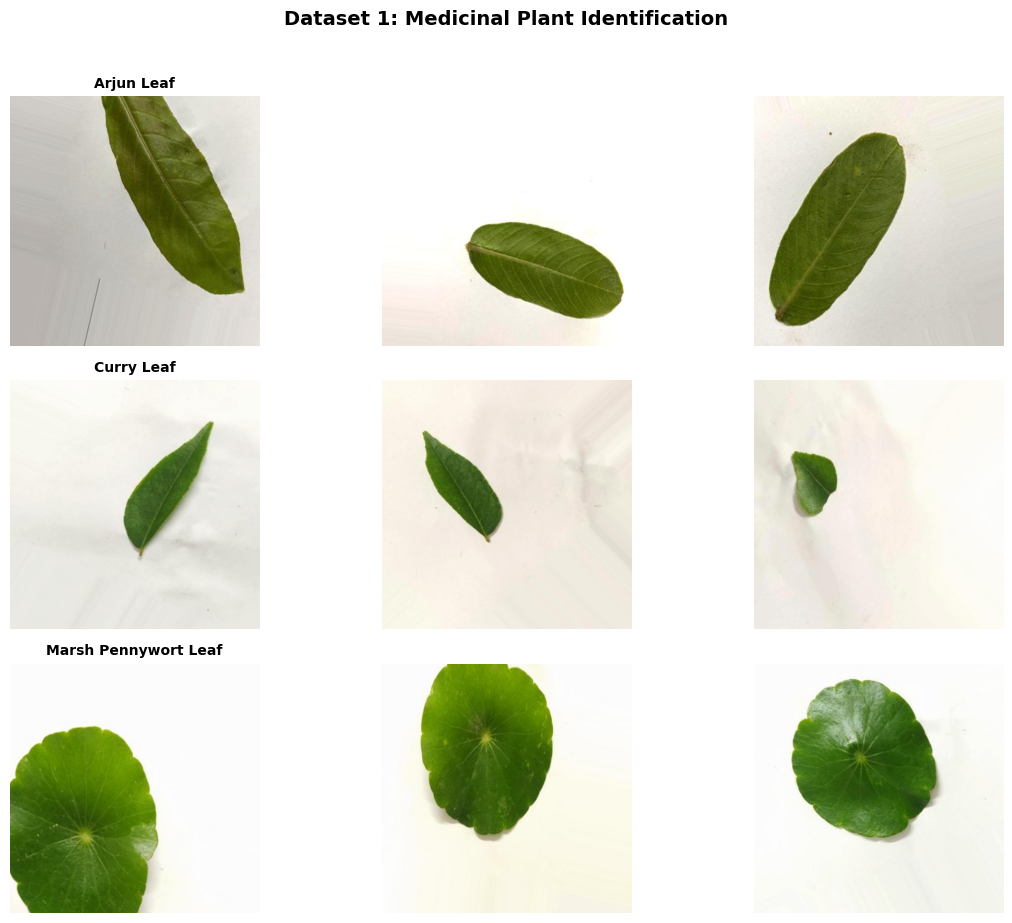

In [ ]:
def show_dataset_samples(path, dataset_name, num_classes=3, num_images=3):
    """Display sample images from a dataset."""
    classes = sorted([d for d in os.listdir(path)
                      if os.path.isdir(os.path.join(path, d)) and not d.startswith('.')])

    classes_to_show = classes[:num_classes]

    fig, axes = plt.subplots(num_classes, num_images, figsize=(12, 3*num_classes))
    fig.suptitle(f'{dataset_name}', fontsize=14, fontweight='bold', y=1.02)

    for row, class_name in enumerate(classes_to_show):
        class_path = os.path.join(path, class_name)
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

        np.random.seed(42 + row)  # for reproducibility
        sample_images = np.random.choice(images, min(num_images, len(images)), replace=False)

        for col, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)

            ax = axes[row, col] if num_classes > 1 else axes[col]
            ax.imshow(img)
            ax.axis('off')
            if col == 0:
                ax.set_title(class_name[:20], fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Show samples from Dataset 1
if "dataset1" in DATASET_PATHS:
    print(">>> Dataset 1 Samples (Phase 1)")
    show_dataset_samples(DATASET_PATHS["dataset1"], "Dataset 1: Medicinal Plant Identification")

>>> Dataset 2 Samples (Phase 2)


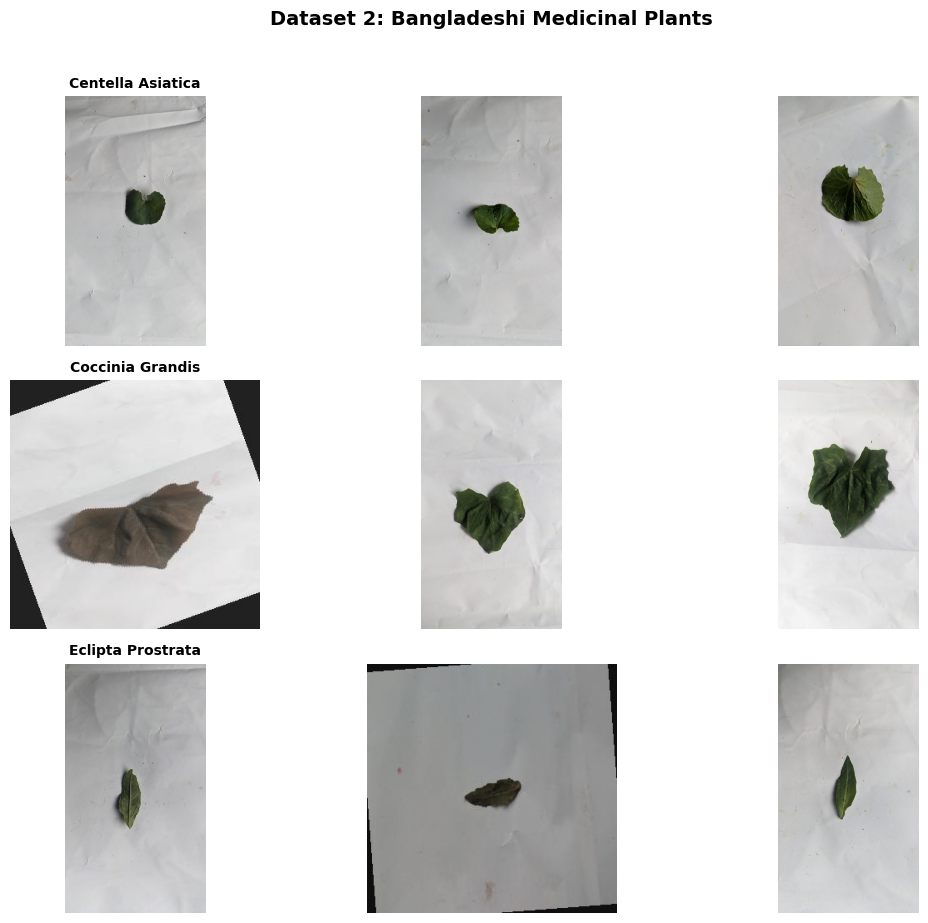

In [ ]:
# Show samples from Dataset 2
if "dataset2" in DATASET_PATHS:
    print(">>> Dataset 2 Samples (Phase 2)")
    show_dataset_samples(DATASET_PATHS["dataset2"], "Dataset 2: Bangladeshi Medicinal Plants")

## 7. Save Config for Other Notebooks

In [ ]:
import json

# Save dataset paths to Google Drive for other notebooks to use
if DATASET_PATHS:
    config = {
        "project_dir": PROJECT_DIR,
        "data_dir": DATA_DIR,
        "model_dir": MODEL_DIR,
        "dataset_paths": DATASET_PATHS,
        "dataset_stats": {
            name: {
                "num_classes": stats["num_classes"],
                "total_images": stats["total_images"],
                "purpose": stats["purpose"]
            }
            for name, stats in dataset_stats.items()
        }
    }

    config_path = os.path.join(PROJECT_DIR, "dataset_config.json")
    with open(config_path, "w") as f:
        json.dump(config, f, indent=2)

    print(f">>>>> Saved: {config_path}")
    print("\nThis config file will be used by the other notebooks.")

>>>>> Saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/dataset_config.json

This config file will be used by the other notebooks.


## 8. Summary & Next Steps

### What's Saved in Google Drive:

```
Google Drive/
└── MedicinalPlant_Dissertation/
    ├── data/
    │   ├── dataset1/  (extracted images)
    │   ├── dataset2/
    │   ├── dataset3/
    │   ├── dataset4/
    │   └── dataset5/
    ├── models/        (trained models will go here)
    └── dataset_config.json
```

### Next Time You Run:
1. Mount Google Drive (1 click)
2. All data loads instantly from Drive
3. No re-downloading required

### Next Step:
Open `02_phase1_baseline.ipynb` to train the baseline model

In [ ]:
print("\n" + "="*60)
print(">>>>> Data Exploration Complete!")
print("="*60)
print(f"\n>>> Datasets ready: {len(DATASET_PATHS)}/{len(DATASETS)}")
print(f"\nData saved to Google Drive:")
print(f"   {PROJECT_DIR}")
print(f"\nNext session: Just mount Drive - no re-download needed!")
print(f"\nNext: Open 02_phase1_baseline.ipynb")


>>>>> Data Exploration Complete!

>>> Datasets ready: 5/5

Data saved to Google Drive:
   /content/drive/MyDrive/MedicinalPlant_Dissertation

Next session: Just mount Drive - no re-download needed!

Next: Open 02_phase1_baseline.ipynb
